<a href="https://colab.research.google.com/github/juangmd63-ai/Analisi_de_estadisticas/blob/main/Analisis_encuestas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Analisis estadisticos de la encuesta de requerimientos, con valores cerrados de una muestra de poblacion**#

#**Cargar datos en excel o CSV**#

#**Nueva seccion**#

In [31]:
from google.colab import files
uploaded = files.upload() # Este es para que se ejecute una ventana que me permita subir el archivo

Saving Validacion_SaaS_Ecommerce_Dashboard (1).xlsx to Validacion_SaaS_Ecommerce_Dashboard (1) (3).xlsx


#**Carga, inspeccion y limpieza de datos**#

# Paso 1: Importar librerias

In [32]:
#Panda para trabajar datos en la tabla de excel
import pandas as pd
#Numpy para crear calculos numericos (Promedio, desviaciones, media, balanza)
import numpy as np
#matplotlib y seaborn: para crear graficas
import matplotlib.pyplot as plt
import seaborn as sns

# Paso 2: Leer un archivo de excel y lo convierte en una tabla en Python, La tabla se llama Dataframe, el cual es una hoja de excel con filas y columnas

In [33]:
#Nombre del archivo y pestaña a leer
nombre_archivo = 'Validacion_SaaS_Ecommerce_Dashboard (1).xlsx'
nombre_pestana = 'Respuestas_Encuesta'

#Cargar los archivos
df = pd.read_excel(nombre_archivo,sheet_name=nombre_pestana)
#Verificar que se cargo los datos correctamente
print(f'archivos cargados: {df.shape[0]} filas y {df.shape[1]} columnas')

archivos cargados: 30 filas y 20 columnas


# Paso 3: Inspeccion de datos

**¿Que es lo que hace? Muestra como se ven los datos y que tipo de informacion tiene, en este caso, la informacion de los requisitos tomados por parte de los clientes**

In [34]:
#Mostrar las primeras 10 filas
print ('Mostrar las primeras 10 filas')
df.head(10)

Mostrar las primeras 10 filas


,ID Comercio,Nombre Comercio,Categoría / Sector,Tamaño Inventario (SKUs),Canales de Venta,P1_Abandono,P2_Impacto1Clic,P3_PagoPref,P4_Autenticacion,P5_Comision1Clic,P6_NumCanales,P7_FrecOverselling,P8_TiempoActualizacion,P9_Centralizacion,P10_TemorSinc,P11_VentasRecurrentes,P12_Suscripciones,P13_FuncionalidadUpsell,P14_AumentoTicket,P15_PrecioSaaS
0,1,Moda Urbana Co,Moda,Mediano (100-1000 SKUs),"Shopify, MercadoLibre, Instagram",51% - 70%,Alto (15%-30% más conversiones),Tarjeta de crédito/débito guardada,Checkout como invitado,"Sí, si aumenta conversión >10%",3-4 canales,Frecuentemente (semanal),1-4 horas,"Stock, precios y gestión unificada de pedidos",Conflictos de duplicación de SKUs,26% - 50%,"No, pero me gustaría implementarlo",Ofertas Post-Compra (1-clic post checkout),16% - 30%,$100 - $199 USD/mes
1,2,TechZone Store,Tecnología,Grande (>1000 SKUs),"Website, Amazon, MercadoLibre",30% - 50%,Moderado (5%-15% más conversiones),Billeteras digitales,Login social,"Tal vez, según volumen",3-4 canales,Frecuentemente (semanal),15-30 minutos,"Stock, precios y gestión unificada de pedidos",Fallas de conexión / Downtime,10% - 25%,No y no me interesa,Bundles/Kits personalizados,5% - 15%,$100 - $199 USD/mes
2,3,Glow Cosmetics,Belleza,Pequeño (<100 SKUs),"Shopify, Instagram",51% - 70%,Alto (15%-30% más conversiones),Tarjeta de crédito/débito guardada,Autenticación silenciosa/OTP,Definitivamente sí,2 canales,Rara vez (1-2 veces/mes),15-30 minutos,Stock y sincronización de precios,Complejidad en la configuración,26% - 50%,"Sí, con una herramienta automatizada",Ofertas Post-Compra (1-clic post checkout),16% - 30%,$49 - $99 USD/mes
3,4,NutriOrganic,Alimentos,Mediano (100-1000 SKUs),"Website, WhatsApp, Rappi",30% - 50%,Alto (15%-30% más conversiones),Transferencia / PSE,Checkout como invitado,"Sí, si aumenta conversión >10%",3-4 canales,Diariamente,1-4 horas,ERP completo integrado,Fallas de conexión / Downtime,Más del 50%,"Sí, de forma manual/artesanal",Recordatorios automáticos de recompra,16% - 30%,$100 - $199 USD/mes
4,5,Hogar & Decora,Hogar,Grande (>1000 SKUs),"Website, MercadoLibre, Falabella",Más del 70%,Crítico (Más del 30%),Tarjeta de crédito/débito guardada,Registro obligatorio,"Tal vez, según volumen",3-4 canales,Diariamente,Manual al final del día,"Stock, precios y gestión unificada de pedidos",Conflictos de duplicación de SKUs,10% - 25%,"No, pero me gustaría implementarlo",Descuentos por volumen dinámicos,5% - 15%,> $200 USD/mes
5,6,FitSport Store,Deportes,Mediano (100-1000 SKUs),"Shopify, Amazon",51% - 70%,Alto (15%-30% más conversiones),Billeteras digitales,Login social,Definitivamente sí,2 canales,Frecuentemente (semanal),15-30 minutos,Stock y sincronización de precios,Costo del software,26% - 50%,"No, pero me gustaría implementarlo",Bundles/Kits personalizados,16% - 30%,$49 - $99 USD/mes
6,7,PetLovers Shop,Mascotas,Pequeño (<100 SKUs),"Shopify, Instagram, WhatsApp",30% - 50%,Moderado (5%-15% más conversiones),Tarjeta de crédito/débito guardada,Checkout como invitado,"Sí, si aumenta conversión >10%",3-4 canales,Rara vez (1-2 veces/mes),1-4 horas,"Stock, precios y gestión unificada de pedidos",Complejidad en la configuración,Más del 50%,"Sí, de forma manual/artesanal",Recordatorios automáticos de recompra,16% - 30%,$49 - $99 USD/mes
7,8,Kiddos Juguetes,Juguetería,Mediano (100-1000 SKUs),"Website, MercadoLibre",51% - 70%,Alto (15%-30% más conversiones),Transferencia / PSE,Registro obligatorio,Definitivamente no,2 canales,Frecuentemente (semanal),1-4 horas,Solo actualización de stock,Conflictos de duplicación de SKUs,10% - 25%,No y no me interesa,Descuentos por volumen dinámicos,5% - 15%,< $49 USD/mes
8,9,BookWorm Librería,Librería,Grande (>1000 SKUs),"Website, Amazon",30% - 50%,Moderado (5%-15% más conversiones),Tarjeta de crédito/débito guardada,Login social,"Tal vez, según volumen",2 canales,Nunca,Automático / Inmediato,"Stock, precios y gestión unificada de pedidos",Costo del software,26% - 50%,"Sí, con una herramienta automati

In [35]:
#Otra forma
print('_________________________________________________________')
display(df.dtypes)

_________________________________________________________


,0
ID Comercio,int64
Nombre Comercio,object
Categoría / Sector,object
Tamaño Inventario (SKUs),object
Canales de Venta,object
P1_Abandono,object
P2_Impacto1Clic,object
P3_PagoPref,object
P4_Autenticacion,object
P5_Comision1Clic,object


# Paso 4: Buscar problemas en los datos:

1. Valores nulos
2. Celdas vacias
3. Filas duplicadas

In [36]:
#Contar valores nulos por columna
print("Valores nulos por columna")
nulos = df.isnull().sum()
print(' Cantidad de nulos son:', nulos)

Valores nulos por columna
 Cantidad de nulos son: ID Comercio                 0
Nombre Comercio             0
Categoría / Sector          0
Tamaño Inventario (SKUs)    0
Canales de Venta            0
P1_Abandono                 0
P2_Impacto1Clic             0
P3_PagoPref                 0
P4_Autenticacion            0
P5_Comision1Clic            0
P6_NumCanales               0
P7_FrecOverselling          0
P8_TiempoActualizacion      0
P9_Centralizacion           0
P10_TemorSinc               0
P11_VentasRecurrentes       0
P12_Suscripciones           0
P13_FuncionalidadUpsell     0
P14_AumentoTicket           0
P15_PrecioSaaS              0
dtype: int64


In [37]:
#Contar filas duplicadas
duplicados = df.duplicated().sum()
print("filas duplicadas: ", duplicados)

filas duplicadas:  0


# Observacion importante:

1. Si una columna tiene muchos nulos > 50%, esta muestra no serviria.
2. Si es inferior a < 50%, se puede trabajar la muestra.

# Paso 5: Limpiar los datos
Elimina espacios de mas al inicio y final de cada texto. Ejemplo " MODA " se convierte en "MODA". Esto es necesario porque si tiene espacios, esta palabras no son iguales

In [38]:
#Seleccionar columnas de texto
columnas_texto = df.select_dtypes(include='object').columns
#Limpiar cada columna
for columna in columnas_texto:
  df[columna] = df[columna].astype(str).str.strip()
#Mostrar relistado de la limpieza
print('Limpieza completada')

Limpieza completada


# Estadisticas descriptivas

La estadística descriptiva es la rama de la estadística que se encarga de recolectar, organizar, resumir, analizar y presentar un conjunto de datos numéricos o cualitativos mediante tablas, gráficos y medidas de resumen.
Su objetivo principal es describir y caracterizar el comportamiento de los datos sin realizar inferencias o generalizaciones sobre una población mayor.

# Herramientas principales
Medidas de Tendencia Central: Indican el valor alrededor del cual se agrupan los datos.

*   Media: El promedio aritmético.
*   Mediana: El valor central cuando los datos están ordenados.
*   Moda: El valor que más se repite.

Medidas de Dispersión: Muestran qué tan alejados o dispersos están los datos respecto a la media.

*   Rango, Varianza, Desviación Estándar y Coeficiente de Variación.



Medidas de Posición: Dividen un conjunto de datos ordenados en partes iguales.Cuartiles, Deciles y Percentiles.

Representación Gráfica: Formas visuales para interpretar la información de manera rápida.

Histogramas, diagramas de barras, diagramas de sectores (pastel), diagramas de caja y bigotes.


# Paso 6: Distribucion por sector

**¿Que** **hace?** texto en negrita Cuenta cuantos comercios hay en cada sector y calcula el porcentaje

In [39]:
#value_conts() cuenta las veces que aparece cada valor
#normalize = True lo convierte en porcentaje
tabla_sector =pd.DataFrame({'Cantidad' : df['Categoría / Sector'].value_counts(),'Porcentaje (%)' : (df['Categoría / Sector'].value_counts(normalize=True)*100).round(2)})

print("Distribucion por sector:")
display(tabla_sector)

Distribucion por sector:


,Cantidad,Porcentaje (%)
Categoría / Sector,,
Moda,4,13.33
Tecnología,4,13.33
Belleza,4,13.33
Alimentos,4,13.33
Hogar,4,13.33
Deportes,2,6.67
Mascotas,2,6.67
Juguetería,2,6.67
Librería,2,6.67


# **7 Tablas cruzadas**

**¿Que hace?** Muestra la relacion entre dos variables. Ejemplo, que sectores estan dispuestos a pagar mas

In [41]:
# pd.crosstab() Crea una tabla que cruza dos variables
# Las filas son sectores, las columnas son rangos de precio

crosstab =pd.crosstab(df['Categoría / Sector'],df['P15_PrecioSaaS'],margins=True)
print("Tabla cruzada vr precio por sector")
display(crosstab)

Tabla cruzada vr precio por sector


P15_PrecioSaaS,$100 - $199 USD/mes,$49 - $99 USD/mes,< $49 USD/mes,> $200 USD/mes,All
Categoría / Sector,,,,,
Alimentos,3,1,0,0,4
Automotriz,0,0,0,2,2
Belleza,2,2,0,0,4
Deportes,1,1,0,0,2
Hogar,1,1,1,1,4
Juguetería,0,1,1,0,2
Librería,0,1,1,0,2
Mascotas,0,2,0,0,2
Moda,2,1,0,1,4


# 8 KPIs indicadores clave

**¿Que hace?** Calcula porcentajes importantes para el negocio, ejemplo, cuantos clientes pago 1 clic


In [42]:
# Kpi 1 : % que considera **Alto** en impacto de pago 1-Clic
#str.contains() busca texto , .mena() calcula promedio, * 100 convierte a %
kpi1 =df['P2_Impacto1Clic'].str.contains('Alto|Crítico', case=False, na=False).mean()*100
# KPI 2: % Con problemas de overselling frecuente
kpi2 =df['P7_FrecOverselling'].str.contains('Frecuentemente|Diariamente', case=False, na=False).mean()*100
print(f"KPI 1: Impacto 1_clic alto|Crítico {kpi1:.2f}%")
print(f"KPI 2: Overselling Frecuente|Diario {kpi2:.2f}%")

KPI 1: Impacto 1_clic alto|Crítico 76.67%
KPI 2: Overselling Frecuente|Diario 56.67%


# 9 Mapeo de texto a numeros

**¿Que hace?** Convierte respuesta de texto a numero para poder hacer calculo, ejemplo, 3 - 4 canales se convierte en 3.5

In [43]:
# Diccionario de conversiones
mapa_canales = {'1 canal':1.0, '2 canales':2.0, '3-4 canales':3.5, '5 o mas canales':5.0}
# aplicar las conversiones
df['NumCanales_Num'] = df['P6_NumCanales'].map(mapa_canales)
#Calcular estadisticas
print(f"Promedio de canales: {df['NumCanales_Num'].mean():.2f}")
print(f"Mediana de canales: {df['NumCanales_Num'].median():.2f}")

Promedio de canales: 2.57
Mediana de canales: 2.00


# Paso 10 Metodo de pago por sector


¿Que hace?
Para cada sector, encuentra cual es el metodo de pago elegido
1. Funcion para obtener la moda de forma segura
2. La "Moda" es el valor que mas se repite

In [46]:
print("Método de pago mas usado por sector:")
def moda_segura(x):
  m=x.mode()
  return m.iloc[0] if not m.empty else 'sin datos'

# agrupar pro sector y encontrar el método  mas usado
pago_por_sector= df.groupby('Categoría / Sector')['P3_PagoPref'].agg(moda_segura)
print("Método de pago mas usado por sector:")
print(pago_por_sector)

Método de pago mas usado por sector:
Método de pago mas usado por sector:
Categoría / Sector
Alimentos     Tarjeta de crédito/débito guardada
Automotriz    Tarjeta de crédito/débito guardada
Belleza       Tarjeta de crédito/débito guardada
Deportes                    Billeteras digitales
Hogar         Tarjeta de crédito/débito guardada
Juguetería                   Transferencia / PSE
Librería      Tarjeta de crédito/débito guardada
Mascotas                    Billeteras digitales
Moda          Tarjeta de crédito/débito guardada
Tecnología                  Billeteras digitales
Name: P3_PagoPref, dtype: object


# Paso 11 Disposicion a pagar comision

**¿Que hace?** Muestra que porcentaje de comision aceptaria pagar una comision extra del 0.5%

In [47]:
# value_conunt(normalize = True) calcula proporsiones
comision_dist=df['P5_Comision1Clic'].value_counts(normalize=True)*100
print("¿Cuantos aceptaria pagar comision del 0.5%")
for respuesta, porcentaje in comision_dist.items():
  print(f"{respuesta}: {porcentaje:.1f}%")

¿Cuantos aceptaria pagar comision del 0.5%
Sí, si aumenta conversión >10%: 36.7%
Tal vez, según volumen: 26.7%
Definitivamente sí: 26.7%
Definitivamente no: 10.0%


# Paso 12 Visualizacion de datos

Apartir de este, son 4 puntos, donde vamos a estar graficando. **¿Por que graficar?**
Una imagen vale mas que 1000 numeros. Las graficas nos ayudan a ver patrones, comparar grupos facilmente y comunicar resultados a otros

# 12.1 Graficas de barras horizontales
¿Que muestra? Se usan barras horizontales porque los nombre son largos

/tmp/ipykernel_399/3373048614.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=upsell_counts.values,y=upsell_counts.index,palette='viridis')


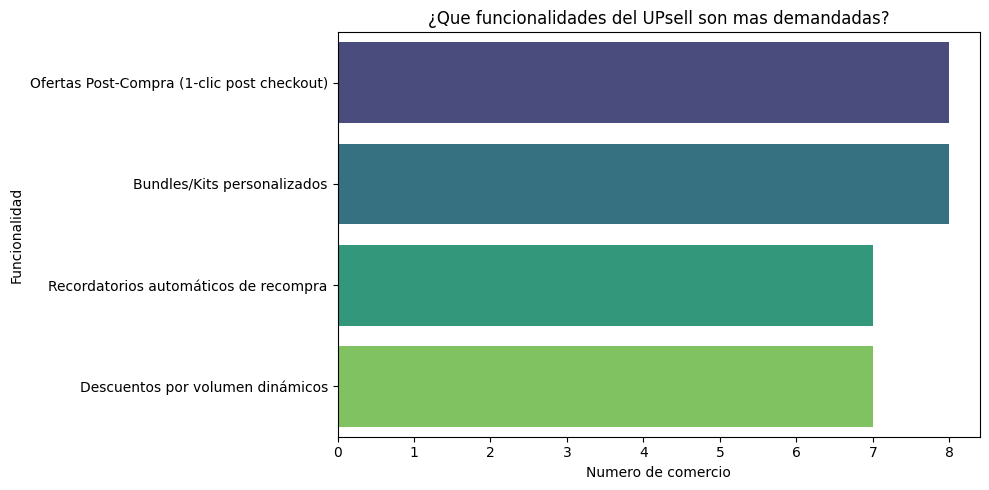

In [49]:
plt.figure(figsize=(10,5))
# Contar cuantos eligieron cada funcionalidad
upsell_counts = df['P13_FuncionalidadUpsell'].value_counts()
# Crear barras horizontales
sns.barplot(x=upsell_counts.values,y=upsell_counts.index,palette='viridis')
# Colocacion de titulos para el diagrama
plt.title('¿Que funcionalidades del UPsell son mas demandadas?')
plt.xlabel('Numero de comercio')
plt.ylabel('Funcionalidad')
plt.tight_layout()
plt.show()
